Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


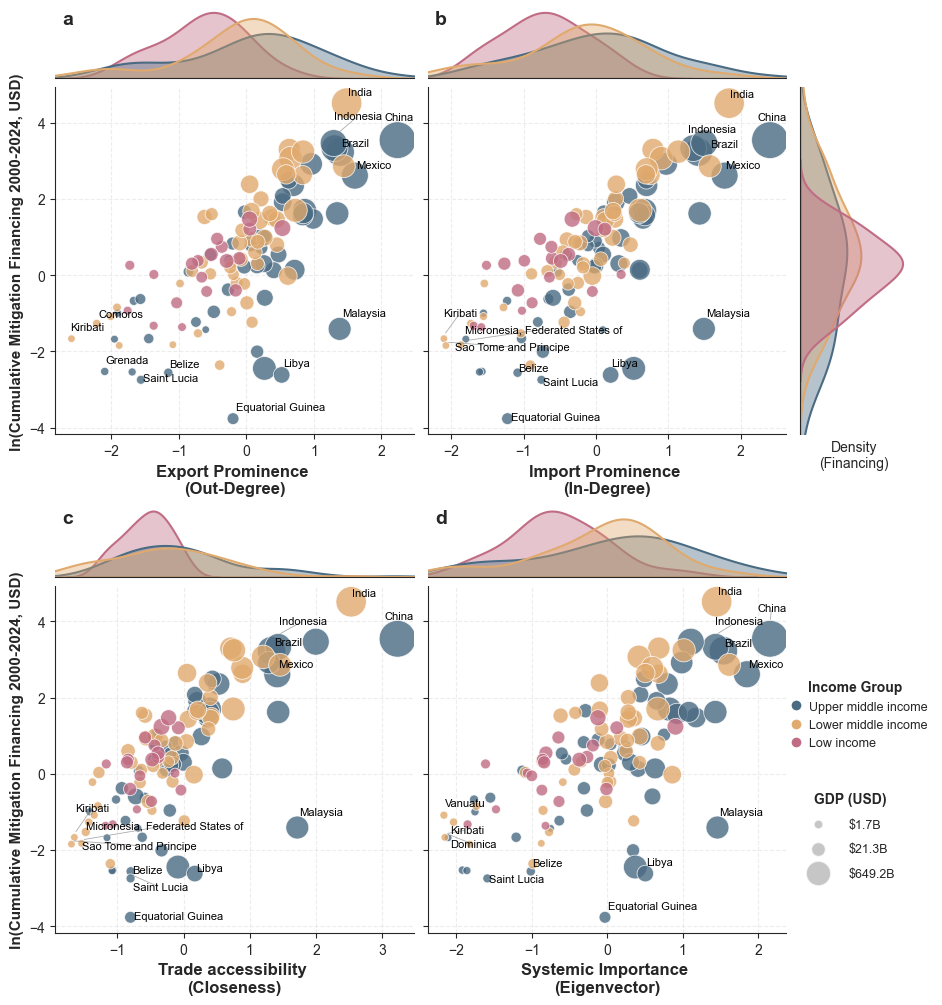

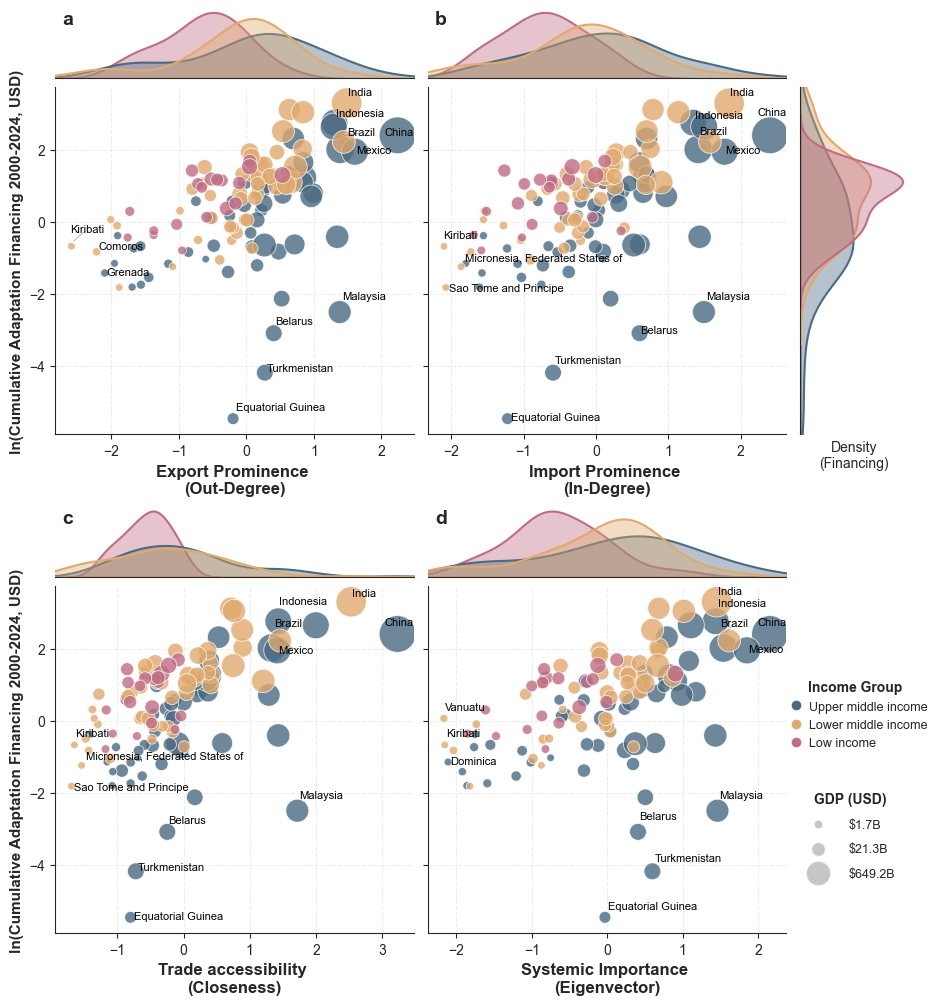

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from adjustText import adjust_text
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. 读取与数据预聚合
# =============================================================================
data = pd.read_csv('../regression_panel_treated.csv')
data.columns = data.columns.str.strip()

if 'Year' in data.columns:
    data.rename(columns={'Year': 'year'}, inplace=True)

financing_sum = data.groupby('Country', as_index=False)[['Total_Mitigation_Finance', 'Total_Adaptation_Finance']].sum()
# 【改动】移除了 'betweenness'
centrality_cols = ['out_degree', 'in_degree', 'closeness', 'eigenvector']
data_2024 = data[data['year'] == 2024][['Country', 'Income group', 'GDP'] + centrality_cols]

# =============================================================================
# 2. 数据处理：针对不同中心度差异化转换与标准化
# =============================================================================
for col in ['in_degree', 'out_degree']:
    data_2024[col] = data_2024[col].replace(0, np.nan)
    data_2024[col] = np.log(data_2024[col])
    data_2024[col] = (data_2024[col] - data_2024[col].mean()) / data_2024[col].std()

# 【改动】移除了 'betweenness'
for col in ['eigenvector']:
    data_2024[col] = np.log(data_2024[col] * 1000000 + 1)
    data_2024[col] = (data_2024[col] - data_2024[col].mean()) / data_2024[col].std()

for col in ['closeness']:
    data_2024[col] = (data_2024[col] - data_2024[col].mean()) / data_2024[col].std()

merged_data_base = pd.merge(data_2024, financing_sum, on='Country', how='left')

# =============================================================================
# 3. 核心绘图函数 (改为 2x2 布局)
# =============================================================================
def plot_finance_centrality_grid(df_base, finance_col, ylabel_text, output_filename, y_max_override=None):
    df_base = df_base[df_base['Income group'] != 'High income'].copy()

    # 使用推荐的稍微深一点的蓝色
    colors_right = {
        'Upper middle income': '#4A6B82', 
        'Lower middle income': '#E0A96D',
        'Low income': '#C06C84'
    }
    sns.set_style("ticks")
    
    cent_labels = {
        'in_degree': 'Import Prominence \n(In-Degree)',
        'out_degree': 'Export Prominence \n(Out-Degree)',
        'closeness': 'Trade accessibility \n(Closeness)',
        'eigenvector': 'Systemic Importance \n(Eigenvector)'
    }
    
    # 【布局改动】调整画布大小为 12x11，更适合 2x2 结构
    fig = plt.figure(figsize=(11, 12)) 
    
    # 【布局改动】创建 4行3列 的网格。
    # 第1列和第2列放主图，第3列放右侧KDE和图例。
    # 行高交替：1(顶部KDE), 5(主图), 1(顶部KDE), 5(主图)
    gs = gridspec.GridSpec(5, 3, 
                           width_ratios=[5, 5, 1.5], 
                           height_ratios=[1, 5, 0.8, 1, 5], 
                           wspace=0.05, hspace=0.05) # hspace 设为 0.05，让 KDE 紧贴主图
    
    # 预先分配坐标轴
    # 0: 入度 (左上), 1: 出度 (右上), 2: 接近中心度 (左下), 3: 特征向量 (右下)
    ax_t0 = fig.add_subplot(gs[0, 0])
    ax_m0 = fig.add_subplot(gs[1, 0], sharex=ax_t0)
    
    ax_t1 = fig.add_subplot(gs[0, 1])
    ax_m1 = fig.add_subplot(gs[1, 1], sharex=ax_t1, sharey=ax_m0)
    
    ax_t2 = fig.add_subplot(gs[3, 0])
    ax_m2 = fig.add_subplot(gs[4, 0], sharex=ax_t2, sharey=ax_m0)
    
    ax_t3 = fig.add_subplot(gs[3, 1])
    ax_m3 = fig.add_subplot(gs[4, 1], sharex=ax_t3, sharey=ax_m0)
    
    ax_mains = [ax_m0, ax_m1, ax_m2, ax_m3]
    ax_tops = [ax_t0, ax_t1, ax_t2, ax_t3]
   
    # 【布局改动】右侧密度图放在右上方，与第一行的主图对齐
    ax_right = fig.add_subplot(gs[1, 2], sharey=ax_m0)
    
    df_valid_gdp = df_base[df_base['GDP'] > 0].copy()
    min_ln_gdp = np.log(df_valid_gdp['GDP']).min()
    max_ln_gdp = np.log(df_valid_gdp['GDP']).max()
    min_size, max_size, power = 30, 700, 2.5
    
    df_fin = df_base[(df_base[finance_col] > 0)].copy()
    df_fin['ln_financing'] = np.log(df_fin[finance_col])
    global_min_y, global_max_y = df_fin['ln_financing'].min(), df_fin['ln_financing'].max()
    
    y_pad = (global_max_y - global_min_y) * 0.05
    y_min_final = global_min_y - y_pad
    y_max_final = global_max_y + y_pad
    if y_max_override is not None: y_max_final = y_max_override
    y_range_tight = y_max_final - y_min_final
    
    manual_countries = [
        'United States', 'Germany', 'United Kingdom', 'China', 'India', 'Indonesia', 
        'Brazil', 'Mexico', 'Vietnam', 'Singapore', 'Saudi Arabia', 'Malaysia'
    ]
    
    for i, cent_col in enumerate(centrality_cols):
        ax_m = ax_mains[i]
        ax_t = ax_tops[i]
        
        # 【新增】在顶部 KDE 密度图(ax_t)的左上角添加 a, b, c, d 标记
        subplot_label = chr(97 + i) 
        ax_t.text(0.02, 0.98, subplot_label, transform=ax_t.transAxes, 
                  fontsize=14, fontweight='bold', va='top', ha='left', zorder=10)
        
        df_plot = df_base[(df_base[finance_col] > 0) & (df_base['GDP'] > 0)].dropna(subset=[cent_col]).copy()
        df_plot['ln_financing'] = np.log(df_plot[finance_col])
        df_plot['plot_cent'] = df_plot[cent_col] 
        df_plot['ln_gdp'] = np.log(df_plot['GDP'])
        
        norm_gdp = (df_plot['ln_gdp'] - min_ln_gdp) / (max_ln_gdp - min_ln_gdp)
        df_plot['point_size'] = min_size + (norm_gdp ** power) * (max_size - min_size)
        
        ax_m.grid(True, linestyle='--', alpha=0.4, color='lightgray', zorder=0)
        
        for group, color in colors_right.items():
            group_data = df_plot[df_plot['Income group'] == group]
            ax_m.scatter(group_data['plot_cent'], group_data['ln_financing'],
                         c=color, s=group_data['point_size'], 
                         alpha=0.8, edgecolor='white', linewidth=0.6, zorder=2)
                         
        sns.kdeplot(data=df_plot, x='plot_cent', hue='Income group',
                    palette=colors_right, fill=True, alpha=0.4, 
                    common_norm=False, linewidth=1.5, legend=False, ax=ax_t)
        
        ax_t.tick_params(axis="both", bottom=False, labelbottom=False, left=False, labelleft=False)
        ax_t.set_ylabel('')
        ax_t.set_xlabel('')
        sns.despine(ax=ax_t, left=True, top=True, right=True)
        
        # 处理 Y 轴标签和刻度 (仅左侧两图显示 Y 轴标签)
        if i % 2 == 0:  # 0和2 (左侧列)
            ax_m.set_ylabel(ylabel_text, fontsize=11, fontweight='bold')
            ax_m.tick_params(labelleft=True)
        else:           # 1和3 (右侧列)
            ax_m.set_ylabel('')
            ax_m.tick_params(labelleft=False)

        min_x, max_x = df_plot['plot_cent'].min(), df_plot['plot_cent'].max()
        x_pad = (max_x - min_x) * 0.05
        ax_m.set_xlim(min_x - x_pad, max_x + x_pad)
        ax_m.set_xlabel(cent_labels[cent_col], fontsize=12, fontweight='bold')
        
        label_df = df_plot[df_plot['Country'].isin(manual_countries)]
        top_fin = df_plot.nlargest(1, 'ln_financing')
        top_cent = df_plot.nlargest(1, 'plot_cent')
        bot_fin = df_plot.nsmallest(4, 'ln_financing') 
        bot_cent = df_plot.nsmallest(3, 'plot_cent')   
        
        label_df = pd.concat([label_df, top_fin, top_cent, bot_fin, bot_cent]).drop_duplicates(subset=['Country'])
        
        texts = []
        for _, row in label_df.iterrows():
            radius_offset = np.sqrt(row['point_size']) * (y_range_tight * 0.0018)
            texts.append(ax_m.text(row['plot_cent'], row['ln_financing'] + radius_offset, 
                                   row['Country'], fontsize=8, color='black', zorder=4))
            
        if texts:
            adjust_text(texts, only_move={'points':'xy', 'text':'y'},
                        force_points=0.8, force_text=1.2,
                        arrowprops=dict(arrowstyle="-", color='#888888', lw=0.6, alpha=0.7),
                        ax=ax_m)
                        
        sns.despine(ax=ax_m)

    ax_m0.set_ylim(y_min_final, y_max_final)
    
    # 绘制右侧融资密度图
    sns.kdeplot(data=df_fin, y='ln_financing', hue='Income group',
                palette=colors_right, fill=True, alpha=0.4, 
                common_norm=False, linewidth=1.5, legend=False, ax=ax_right)
    ax_right.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False)
    ax_right.set_xlabel('Density\n(Financing)', fontsize=10)
    ax_right.set_ylabel('')
    sns.despine(ax=ax_right, bottom=True, top=True, right=True)

    # =========================================================================
    # 【布局改动】将图例放置在右下角的留白区域 (以 ax_m3 为锚点向右偏移)
    # =========================================================================
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=k,
                              markerfacecolor=v, markersize=8) for k, v in colors_right.items()]
    leg1 = ax_m3.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.96, 0.76),
                        frameon=False, fontsize=9, title='Income Group', title_fontproperties={'weight':'bold'}, handletextpad=0.05)
    ax_m3.add_artist(leg1)

    target_gdps = df_valid_gdp['GDP'].quantile([0.1, 0.5, 0.95]).values
    size_refs, size_labels = [], []
    for val in target_gdps:
        ln_val = np.log(val)
        norm_val = max(0, min(1, (ln_val - min_ln_gdp) / (max_ln_gdp - min_ln_gdp))) 
        calc_size = min_size + (norm_val ** power) * (max_size - min_size)
        size_refs.append(calc_size)
        
        if val >= 1e12: label = f'${val/1e12:.1f}T'
        elif val >= 1e9: label = f'${val/1e9:.1f}B'
        elif val >= 1e6: label = f'${val/1e6:.1f}M'
        else: label = f'${val:,.0f}'
        size_labels.append(label)

    size_handles = [plt.scatter([], [], s=s, marker='o', color='#A0A0A0', alpha=0.6, edgecolor='white') for s in size_refs]
    leg2 = ax_m3.legend(size_handles, size_labels, loc='upper left', bbox_to_anchor=(1.0, 0.46),
                        frameon=False, fontsize=9, title='GDP (USD)', 
                        title_fontproperties={'weight':'bold'},
                        labelspacing=1, borderpad=1, handletextpad=1.5)

    plt.savefig(output_filename, dpi=300, bbox_inches='tight', bbox_extra_artists=(leg1, leg2))
    plt.show()
    
# =============================================================================
# 4. 执行绘图
# =============================================================================
plot_finance_centrality_grid(
    df_base=merged_data_base, 
    finance_col='Total_Mitigation_Finance', 
    ylabel_text='ln(Cumulative Mitigation Financing 2000-2024, USD)', 
    output_filename='Final/Fig.3_Mitigation_4Centralities_Std.pdf' # 【改动】调整了文件名以反映4个维度
)

plot_finance_centrality_grid(
    df_base=merged_data_base, 
    finance_col='Total_Adaptation_Finance', 
    ylabel_text='ln(Cumulative Adaptation Financing 2000-2024, USD)', 
    output_filename='Final/Fig.3_Adaptation_4Centralities_Std.pdf', # 【改动】调整了文件名以反映4个维度
    # y_max_override=18
)